In [1]:
# ============================================================
# PHASE — DELAY PROPAGATION ANALYSIS
# HONEST FRAMING: correlation-based, not causal
# (no hub-level timestamps available in dataset)
# Run after phase3.py
# ============================================================

import pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

with open('phase3_checkpoint.pkl', 'rb') as f:
    p3 = pickle.load(f)

corridor_stats = p3['corridor_stats']
hub_df         = p3['hub_df']
G              = p3['G']
THRESHOLD_SEVERE = p3['THRESHOLD_SEVERE']

print("✅ Loaded")
print("\n⚠ METHODOLOGY NOTE:")
print("  True causal propagation requires hub-level timestamps (not available).")
print("  This analysis uses graph-structural propagation:")
print("  If Hub A has high delay, do its downstream neighbors also have high delay?")
print("  This measures correlation, not causation. Stated explicitly throughout.")

✅ Loaded

⚠ METHODOLOGY NOTE:
  True causal propagation requires hub-level timestamps (not available).
  This analysis uses graph-structural propagation:
  If Hub A has high delay, do its downstream neighbors also have high delay?
  This measures correlation, not causation. Stated explicitly throughout.


In [2]:
# ── Build Delay-Weighted Graph ────────────────────────────────
# Edge weight = median delay ratio on that corridor
corridor_lookup = corridor_stats.groupby(
    ['source_center','destination_center']
)['median_delay_ratio'].median().reset_index()
corridor_lookup.columns = ['src','dst','delay_ratio']

G_delay = nx.DiGraph()
for _, row in corridor_lookup.iterrows():
    G_delay.add_edge(str(row['src']), str(row['dst']),
                     weight=row['delay_ratio'])

print(f"\nDelay graph: {G_delay.number_of_nodes()} nodes | "
      f"{G_delay.number_of_edges()} edges")


Delay graph: 1657 nodes | 2781 edges


In [6]:
# ── Propagation Score ─────────────────────────────────────────
# For each hub: propagation_score = own_delay × sum(downstream_neighbor_delays)
# Logic: a hub propagates if it's delayed AND its successors are also delayed

hub_index = hub_df.set_index('facility')

def get_downstream_avg_delay(node, G, depth=2):
    """Average delay of nodes reachable within `depth` hops"""
    reachable = set()
    frontier  = {node}
    for _ in range(depth):
        next_frontier = set()
        for n in frontier:
            next_frontier.update(G.successors(n))
        reachable.update(next_frontier)
        frontier = next_frontier
    if not reachable:
        return 0.0
    delays = []
    for n in reachable:
        if n in hub_index.index:
            delays.append(hub_index.loc[n, 'avg_incoming_delay'])
    return np.mean(delays) if delays else 0.0

def get_upstream_avg_delay(node, G, depth=2):
    """Average delay of nodes that feed into this node"""
    reachable = set()
    frontier  = {node}
    for _ in range(depth):
        next_frontier = set()
        for n in frontier:
            next_frontier.update(G.predecessors(n))
        reachable.update(next_frontier)
        frontier = next_frontier
    if not reachable:
        return 0.0
    delays = []
    for n in reachable:
        if n in hub_index.index:
            delays.append(hub_index.loc[n, 'outgoing_severe_rate'])
    return np.mean(delays) if delays else 0.0

print("Computing propagation scores (takes ~2 min for 1657 nodes)...")

propagation_data = []
nodes_in_both    = [n for n in G_delay.nodes() if n in hub_index.index]

for i, node in enumerate(nodes_in_both):
    if (i+1) % 200 == 0:
        print(f"  Processed {i+1}/{len(nodes_in_both)}...")

    own_delay        = hub_index.loc[node, 'avg_incoming_delay']
    own_severe_rate  = hub_index.loc[node, 'outgoing_severe_rate']
    downstream_delay = get_downstream_avg_delay(node, G_delay, depth=2)
    upstream_delay   = get_upstream_avg_delay(node, G_delay, depth=2)
    out_deg          = G_delay.out_degree(node)
    in_deg           = G_delay.in_degree(node)

    # Propagation score: hub propagates delays if it's delayed AND downstream is delayed
    # Formula: own_severe_rate × downstream_avg_delay × log(1+out_degree)
    propagation_score = (
        own_severe_rate *
        downstream_delay *
        np.log1p(out_deg)
    )

    # Downstream impact: how much does upstream delay predict my delay?
    downstream_impact_score = upstream_delay * own_severe_rate * np.log1p(in_deg)

    propagation_data.append({
        'facility':               node,
        'own_delay':              own_delay,
        'own_severe_rate':        own_severe_rate,
        'downstream_avg_delay':   downstream_delay,
        'upstream_avg_delay':     upstream_delay,
        'out_degree':             out_deg,
        'in_degree':              in_deg,
        'propagation_score':      propagation_score,
        'downstream_impact_score':downstream_impact_score,
    })

prop_df = pd.DataFrame(propagation_data).fillna(0)

# Normalize scores 0-100
prop_df['propagation_score_norm']      = (
    (prop_df['propagation_score'] - prop_df['propagation_score'].min()) /
    (prop_df['propagation_score'].max() - prop_df['propagation_score'].min() + 1e-8)
) * 100

prop_df['impact_score_norm'] = (
    (prop_df['downstream_impact_score'] - prop_df['downstream_impact_score'].min()) /
    (prop_df['downstream_impact_score'].max() - prop_df['downstream_impact_score'].min() + 1e-8)
) * 100

# Classify hub roles
source_mask = (
    (prop_df['propagation_score_norm'] > 60) &
    (prop_df['upstream_avg_delay'] < prop_df['upstream_avg_delay'].median())
)
prop_df.loc[source_mask, 'hub_role'] = 'Delay Source'

# Amplifier: both high — receives delayed shipments AND propagates further
amp_mask = (
    (prop_df['propagation_score_norm'] > 40) &
    (prop_df['upstream_avg_delay'] > prop_df['upstream_avg_delay'].quantile(0.6))
)
prop_df.loc[amp_mask, 'hub_role'] = 'Delay Amplifier'

# Receiver: high incoming, low outgoing — absorbs delay without propagating
print("\nPropagation score distribution:")
print(prop_df['propagation_score_norm'].describe())

print("\nImpact score distribution:")
print(prop_df['impact_score_norm'].describe())

# Receiver: absorbs upstream delay, low outgoing propagation
receiver_mask = (
    (prop_df['impact_score_norm'] >
        prop_df['impact_score_norm'].quantile(0.70)) &
    (prop_df['propagation_score_norm'] <
        prop_df['propagation_score_norm'].quantile(0.60)) &
    (prop_df['in_degree'] > 0)
)

prop_df.loc[receiver_mask, 'hub_role'] = 'Delay Receiver'
prop_df.loc[
    (prop_df['propagation_score_norm'] > prop_df['propagation_score_norm'].quantile(0.8)) &
    (prop_df['impact_score_norm'] < prop_df['impact_score_norm'].quantile(0.5)),
    'hub_role'
] = 'Delay Source'

prop_df.loc[
    (prop_df['impact_score_norm'] > prop_df['impact_score_norm'].quantile(0.8)) &
    (prop_df['propagation_score_norm'] < prop_df['propagation_score_norm'].quantile(0.5)),
    'hub_role'
] = 'Delay Receiver'

prop_df.loc[
    (prop_df['propagation_score_norm'] > prop_df['propagation_score_norm'].quantile(0.8)) &
    (prop_df['impact_score_norm'] > prop_df['impact_score_norm'].quantile(0.8)),
    'hub_role'
] = 'Delay Amplifier'

print(f"\n=== HUB ROLE CLASSIFICATION ===")
print(prop_df['hub_role'].value_counts())

print(f"\n=== TOP 10 DELAY SOURCES (propagate most) ===")
print(prop_df[prop_df['hub_role']=='Delay Source']
      .nlargest(10,'propagation_score_norm')[
          ['facility','own_severe_rate','downstream_avg_delay',
           'out_degree','propagation_score_norm']
      ].round(3).to_string())

print(f"\n=== TOP 10 DELAY AMPLIFIERS (receive AND propagate) ===")
print(prop_df[prop_df['hub_role']=='Delay Amplifier']
      .nlargest(10,'propagation_score_norm')[
          ['facility','own_severe_rate','upstream_avg_delay',
           'downstream_avg_delay','propagation_score_norm']
      ].round(3).to_string())

print(prop_df['hub_role'].value_counts())

Computing propagation scores (takes ~2 min for 1657 nodes)...
  Processed 200/1657...
  Processed 400/1657...
  Processed 600/1657...
  Processed 800/1657...
  Processed 1000/1657...
  Processed 1200/1657...
  Processed 1400/1657...
  Processed 1600/1657...

Propagation score distribution:
count    1657.000000
mean        3.368977
std         5.724112
min         0.000000
25%         0.000000
50%         1.469886
75%         4.550627
max       100.000000
Name: propagation_score_norm, dtype: float64

Impact score distribution:
count    1657.000000
mean        3.144554
std         7.571622
min         0.000000
25%         0.000000
50%         0.519465
75%         2.947006
max        99.999999
Name: impact_score_norm, dtype: float64

=== HUB ROLE CLASSIFICATION ===
hub_role
Delay Amplifier    233
Delay Source        60
Delay Receiver      42
Name: count, dtype: int64

=== TOP 10 DELAY SOURCES (propagate most) ===
          facility  own_severe_rate  downstream_avg_delay  out_degree  propa

In [7]:
# ── Delay Amplification Corridors ────────────────────────────
# Corridors where downstream delay > upstream delay (amplification)
corridor_propagation = []
for u, v, data in G_delay.edges(data=True):
    if u in hub_index.index and v in hub_index.index:
        src_delay = hub_index.loc[u, 'avg_incoming_delay']
        dst_delay = hub_index.loc[v, 'avg_incoming_delay']
        amplification = dst_delay - src_delay
        corridor_propagation.append({
            'source': u, 'destination': v,
            'edge_delay': data.get('weight', 1.0),
            'src_hub_delay': src_delay,
            'dst_hub_delay': dst_delay,
            'amplification': amplification
        })

corr_prop_df = pd.DataFrame(corridor_propagation)
amplifying   = corr_prop_df[corr_prop_df['amplification'] > 0]
print(f"\n=== DELAY AMPLIFICATION CORRIDORS ===")
print(f"Corridors where downstream hub is MORE delayed than upstream: "
      f"{len(amplifying)} / {len(corr_prop_df)} ({len(amplifying)/len(corr_prop_df):.1%})")
print("\nTop 10 amplifying corridors:")
print(amplifying.nlargest(10,'amplification')[
    ['source','destination','edge_delay','src_hub_delay','dst_hub_delay','amplification']
].round(3).to_string())


=== DELAY AMPLIFICATION CORRIDORS ===
Corridors where downstream hub is MORE delayed than upstream: 1490 / 2781 (53.6%)

Top 10 amplifying corridors:
            source   destination  edge_delay  src_hub_delay  dst_hub_delay  amplification
813   IND221313AAA  IND221401AAA      16.714          1.908         16.714         14.806
1515  IND842003AAB  IND482002AAA      15.375          2.400         15.375         12.975
1584  IND493445AAB  IND490023AAA      14.410          1.744         14.410         12.666
1285  IND400072AAI  IND000000AFS       9.417          0.000          9.417          9.417
2370  IND713205AAB  IND722101AAB      10.096          2.162         10.096          7.934
432   IND751002AAB  IND754103AAA      10.250          1.895          9.568          7.672
1585  IND495004AAA  IND495671AAA       3.111          0.000          6.588          6.588
1269  IND400072AAJ  IND400037AAA       9.000          2.970          9.000          6.030
1071  IND311301AAA  IND305624AAA       


Plot saved: delay_propagation.png


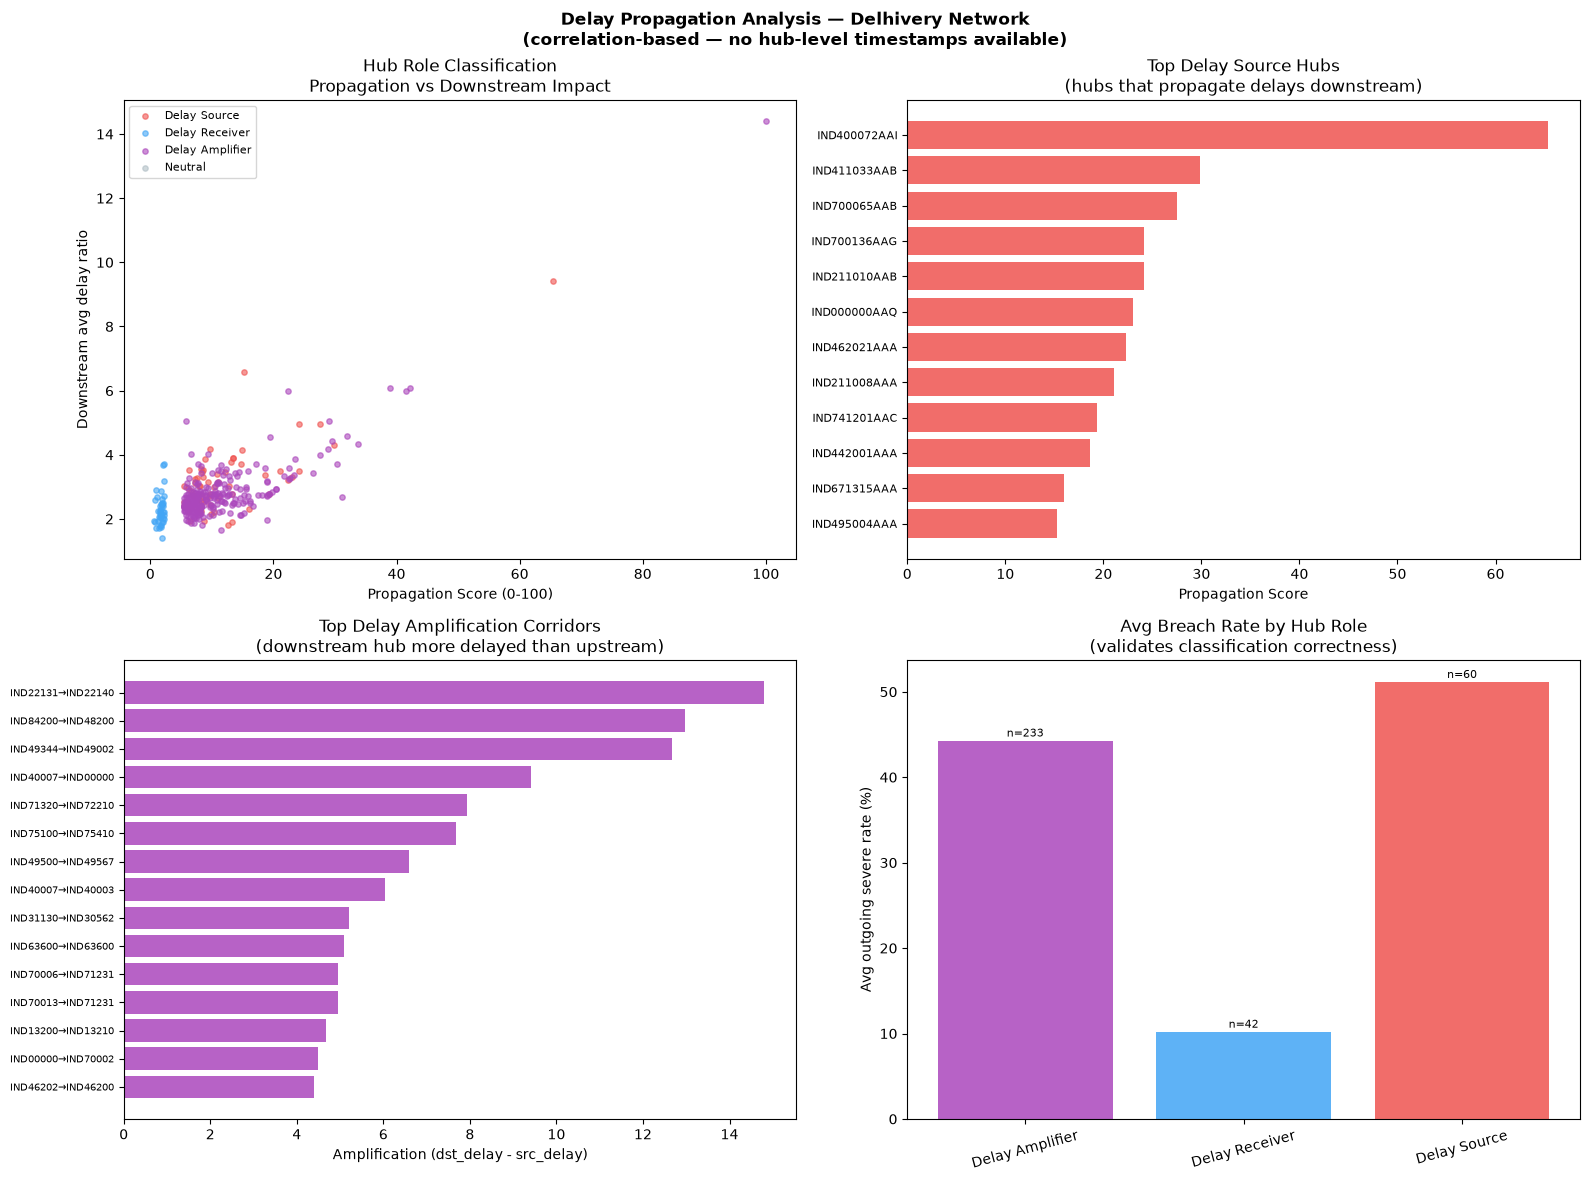


BUSINESS INTERPRETATION

Hub role summary:
  Delay Sources (propagate outward):     60
  Delay Amplifiers (receive+propagate):  233
  Delay Receivers (absorb upstream):     42

Key finding:
  54% of corridors show delay amplification
  Delay Amplifiers are highest priority — fixing them breaks propagation chains

⚠ Limitation: analysis is correlation-based.
  Causal validation requires hub-level entry/exit timestamps.
  Treat findings as hypothesis generation, not confirmed causal claims.
✅ Saved propagation_results.pkl


In [8]:
# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Propagation score vs downstream delay (scatter by role)
role_colors = {
    'Delay Source':    '#EF5350',
    'Delay Receiver':  '#42A5F5',
    'Delay Amplifier': '#AB47BC',
    'Neutral':         '#B0BEC5'
}
for role, color in role_colors.items():
    subset = prop_df[prop_df['hub_role']==role]
    axes[0,0].scatter(subset['propagation_score_norm'],
                      subset['downstream_avg_delay'],
                      c=color, alpha=0.6, s=15, label=role)
axes[0,0].set_xlabel('Propagation Score (0-100)')
axes[0,0].set_ylabel('Downstream avg delay ratio')
axes[0,0].set_title('Hub Role Classification\nPropagation vs Downstream Impact')
axes[0,0].legend(fontsize=8)

# 2. Top delay sources ranking
sources = prop_df[prop_df['hub_role']=='Delay Source'].nlargest(12,'propagation_score_norm')
axes[0,1].barh(range(len(sources)), sources['propagation_score_norm'].values,
               color='#EF5350', alpha=0.85)
axes[0,1].set_yticks(range(len(sources)))
axes[0,1].set_yticklabels([f[:12] for f in sources['facility'].values], fontsize=8)
axes[0,1].set_xlabel('Propagation Score')
axes[0,1].set_title('Top Delay Source Hubs\n(hubs that propagate delays downstream)')
axes[0,1].invert_yaxis()

# 3. Amplification corridors
top_amp = amplifying.nlargest(15,'amplification')
top_amp['label'] = (top_amp['source'].str[:8] + '→' +
                    top_amp['destination'].str[:8])
axes[1,0].barh(range(len(top_amp)), top_amp['amplification'].values,
               color='#AB47BC', alpha=0.85)
axes[1,0].set_yticks(range(len(top_amp)))
axes[1,0].set_yticklabels(top_amp['label'].values, fontsize=7)
axes[1,0].set_xlabel('Amplification (dst_delay - src_delay)')
axes[1,0].set_title('Top Delay Amplification Corridors\n'
                    '(downstream hub more delayed than upstream)')
axes[1,0].invert_yaxis()

# 4. Role distribution + own_severe_rate by role
role_stats = prop_df.groupby('hub_role').agg(
    count=('facility','count'),
    avg_severe_rate=('own_severe_rate','mean'),
    avg_prop_score=('propagation_score_norm','mean')
).reset_index()
axes[1,1].bar(role_stats['hub_role'], role_stats['avg_severe_rate']*100,
              color=[role_colors.get(r,'gray') for r in role_stats['hub_role']],
              alpha=0.85)
axes[1,1].set_ylabel('Avg outgoing severe rate (%)')
axes[1,1].set_title('Avg Breach Rate by Hub Role\n'
                    '(validates classification correctness)')
axes[1,1].tick_params(axis='x', rotation=15)
for i, row in role_stats.iterrows():
    axes[1,1].text(i, row['avg_severe_rate']*100+0.5,
                   f"n={row['count']}", ha='center', fontsize=8)

plt.suptitle('Delay Propagation Analysis — Delhivery Network\n'
             '(correlation-based — no hub-level timestamps available)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('delay_propagation.png', dpi=150, bbox_inches='tight')
print("\nPlot saved: delay_propagation.png")
plt.show()

print("\n" + "="*55)
print("BUSINESS INTERPRETATION")
print("="*55)
n_sources    = (prop_df['hub_role']=='Delay Source').sum()
n_amplifiers = (prop_df['hub_role']=='Delay Amplifier').sum()
n_receivers  = (prop_df['hub_role']=='Delay Receiver').sum()
print(f"\nHub role summary:")
print(f"  Delay Sources (propagate outward):     {n_sources}")
print(f"  Delay Amplifiers (receive+propagate):  {n_amplifiers}")
print(f"  Delay Receivers (absorb upstream):     {n_receivers}")
print(f"\nKey finding:")
print(f"  {len(amplifying)/len(corr_prop_df):.0%} of corridors show delay amplification")
print(f"  Delay Amplifiers are highest priority — fixing them breaks propagation chains")
print(f"\n⚠ Limitation: analysis is correlation-based.")
print(f"  Causal validation requires hub-level entry/exit timestamps.")
print(f"  Treat findings as hypothesis generation, not confirmed causal claims.")

with open('propagation_results.pkl', 'wb') as f:
    pickle.dump({'prop_df': prop_df, 'corr_prop_df': corr_prop_df}, f, protocol=4)
print("✅ Saved propagation_results.pkl")